# 01 - MDPs and Value-Based Learning

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Make sure we get outputs from a probabilitistic model each time (for reproducibility)
np.random.seed(1515)

## From One Decision to a Sequence of Decisions

`deep_learning_primer/02-value-and-policy-networks.ipynb` trained a value network on fixed "pick score" labels for each team, considered one at a time and independently. But recall `frc_resources/01_frc_intro/README.md`: an alliance captain drafts 2-3 partners *in sequence*, and the second pick's value depends entirely on what the first pick already covers. That's not a fact you can capture by scoring each team in isolation - it's a genuine multi-step decision problem, and it's exactly what a **Markov Decision Process (MDP)** is built to describe.

## The FRC Draft as an MDP

We'll build a small, fully worked-out draft: 3 candidate teams, and our alliance captain needs to pick 2 of them, one at a time.

| Team | Climb Rate | Auto Score | Style |
|---|---|---|---|
| A | 0.9 | 1.0 | climb specialist |
| B | 0.1 | 4.5 | auto specialist |
| C | 0.5 | 2.5 | generalist |

- **State**: which teams remain undrafted, and which we've already picked.
- **Action**: pick one of the remaining teams.
- **Reward**: each pick immediately scores `quality(team) = climb_rate * 5 + auto_score`. On the *final* pick, an additional **synergy bonus of +5** is added if our two picks together cover both a strong climber (climb rate > 0.7) *and* a strong auto scorer (auto score > 4.0) - a delayed reward that depends on both picks together, not either one alone.
- **Episode**: exactly 2 picks, then done.

In [2]:
TEAMS = {
    'A': {'climb': 0.9, 'auto': 1.0},
    'B': {'climb': 0.1, 'auto': 4.5},
    'C': {'climb': 0.5, 'auto': 2.5},
}

def quality(team):
    return team['climb'] * 5 + team['auto']

class DraftEnv:
    """An MDP for drafting `num_picks` teams out of `teams`, one at a time."""
    def __init__(self, teams, num_picks):
        self.teams = teams
        self.num_picks = num_picks

    def reset(self):
        self.remaining = tuple(sorted(self.teams.keys()))
        self.picked = tuple()
        self.done = False
        return self._state()

    def _state(self):
        return (self.remaining, self.picked)

    def valid_actions(self):
        return self.remaining

    def _synergy_bonus(self):
        has_climber = any(self.teams[t]['climb'] > 0.7 for t in self.picked)
        has_auto = any(self.teams[t]['auto'] > 4.0 for t in self.picked)
        return 5.0 if (has_climber and has_auto) else 0.0

    def step(self, action):
        assert action in self.remaining, f"{action} is not a valid pick right now"
        reward = quality(self.teams[action])
        self.picked = self.picked + (action,)
        self.remaining = tuple(t for t in self.remaining if t != action)
        self.done = (len(self.picked) == self.num_picks)
        if self.done:
            reward += self._synergy_bonus()
        return self._state(), reward, self.done

This `reset()`/`step()` shape is the same idea as the explicit states-and-transitions model from `back_end_resources/systems_primer/03_state_machines` - the difference is that here, *we* (the agent) choose which transition to take by picking an action, and every transition carries a reward with it.

In [3]:
# sanity check: walk both branches by hand before any learning algorithm touches this
env = DraftEnv(TEAMS, num_picks=2)

for first_pick, second_pick in [('A', 'B'), ('C', 'A')]:
    env.reset()
    _, r1, _ = env.step(first_pick)
    _, r2, done = env.step(second_pick)
    print(f"Pick {first_pick} then {second_pick}: reward1={r1:.1f}, reward2={r2:.1f}, "
          f"total={r1 + r2:.1f}")

Pick A then B: reward1=5.5, reward2=10.0, total=15.5
Pick C then A: reward1=5.0, reward2=5.5, total=10.5


Picking A then B (climb specialist + auto specialist, covering both needs) beats picking C then A - the synergy bonus is what makes the difference. A good scout could reason this out by hand for 3 teams; the whole point of the rest of this notebook is a way to find this same answer automatically, from experience, for a draft too large to reason through by hand.

## Return and the Discount Factor

The **Return** is the total reward accumulated over an episode. With a **Discount Factor** $\gamma$ (a number between 0 and 1), rewards further in the future count slightly less:

$$ G_t = r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + \dots $$

Discounting matters more in longer episodes than our 2-step draft (it's also what keeps an infinitely long episode's return from summing to infinity), but we'll use $\gamma = 0.9$ throughout this notebook anyway, since real drafts and real training data are noisy in ways our hand-built example isn't - discounting a little makes an algorithm trust its own longer-range guesses a bit less than its immediate, already-observed rewards.

## Q-Learning: Learning Values from Experience, Not a Formula

We already worked out the best draft order by hand above, because this MDP is small enough to reason through directly. **Q-Learning** finds the same answer without ever being told the reward formula - only by trying actions and observing what comes back. Its update rule for the **Action-Value Function** $Q(s, a)$:

$$ Q(s, a) \leftarrow Q(s, a) + \alpha \Big[ \underbrace{r + \gamma \max_{a'} Q(s', a')}_{\text{TD target}} - Q(s, a) \Big] $$

The **TD target** - reward plus our own current best guess about everything afterward - is a guess built partly from a guess. The gap between that target and our current $Q(s,a)$ is the **TD Error**, and it's what nudges $Q(s,a)$ a little closer to the target on every single step, long before the episode (or, in a longer problem, the whole season) is even over.

In [4]:
gamma = 0.9
alpha = 0.1
epsilon = 0.1
n_episodes = 5000

Q = defaultdict(float)
initial_state = (('A', 'B', 'C'), tuple())
q_history = {a: [] for a in TEAMS}

for episode in range(n_episodes):
    state = env.reset()
    done = False
    while not done:
        valid_actions = env.valid_actions()
        if np.random.rand() < epsilon:
            action = valid_actions[np.random.randint(len(valid_actions))]
        else:
            q_values = [Q[(state, a)] for a in valid_actions]
            action = valid_actions[int(np.argmax(q_values))]

        next_state, reward, done = env.step(action)

        if done:
            max_next_q = 0.0
        else:
            next_valid = env.valid_actions()
            max_next_q = max(Q[(next_state, a2)] for a2 in next_valid)

        td_target = reward + gamma * max_next_q
        td_error = td_target - Q[(state, action)]
        Q[(state, action)] += alpha * td_error

        state = next_state

    for a in TEAMS:
        q_history[a].append(Q[(initial_state, a)])

print("Learned Q-values for the first pick:")
for a in TEAMS:
    print(f"  Q(initial, pick {a}) = {Q[(initial_state, a)]:.2f}")

Learned Q-values for the first pick:
  Q(initial, pick A) = 14.50
  Q(initial, pick B) = 14.45
  Q(initial, pick C) = 9.95


By hand (using the same reward formula, with $\gamma = 0.9$): $Q(\text{initial}, A) \approx 14.5$, $Q(\text{initial}, B) \approx 14.45$ - nearly tied, both clearly ahead of $Q(\text{initial}, C) \approx 9.95$. Q-learning should have arrived at numbers close to these purely from repeated trial and error, with no reward formula ever given to it directly.

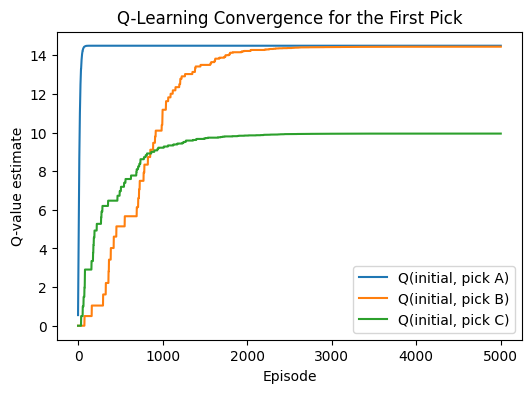

Greedy policy's first pick: A


In [5]:
plt.figure(figsize=(6, 4))
for a in TEAMS:
    plt.plot(q_history[a], label=f'Q(initial, pick {a})')
plt.xlabel('Episode')
plt.ylabel('Q-value estimate')
plt.title('Q-Learning Convergence for the First Pick')
plt.legend()
plt.show()

best_first_pick = max(TEAMS, key=lambda a: Q[(initial_state, a)])
print(f"Greedy policy's first pick: {best_first_pick}")

## From a Table to a Network: Deep Q-Learning

Our Q-table only ever needed 9 entries, because there are only 3 possible teams. A real scouting pool has dozens of candidates, each described by continuous stats - the state space stops being something you can enumerate at all, and the agent will constantly face stat combinations it has never seen in that exact combination before. A table has no entry for a state it's never visited; a neural network can generalize to it from similar states it has seen. Recall the **Value Network** from `deep_learning_primer/02` - same architecture, but now its training target is the TD target above, recomputed from the network's *own* current prediction, instead of a fixed label.

One design point matters here that didn't come up when we only had a lookup table: our feature vector has to fully capture the state, or two genuinely different situations can collide into the exact same input. If we only encode `[climb, auto, already_have_a_climber, already_have_an_auto_scorer]`, then "no picks made yet" and "already picked team C" produce the *identical* feature vector whenever the already-picked team happens not to satisfy either need - C does neither (its climb rate and auto score both fall short of the thresholds) - even though the correct Q-value is very different in each case, since one of them still has a pick left to make and the other doesn't. We fix this by adding one more feature: how many picks remain.

In [6]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def features(team_name, picked):
    """[climb, auto, already_have_a_climber, already_have_an_auto_scorer, picks_remaining]
    Centered around 0 (rather than left as raw positive numbers) - a ReLU network
    whose inputs are all positive can get stuck with permanently "dead" hidden units,
    the same reason ml_primer/03's pipelines used StandardScaler before fitting."""
    team = TEAMS[team_name]
    has_climber = 1.0 if any(TEAMS[t]['climb'] > 0.7 for t in picked) else 0.0
    has_auto = 1.0 if any(TEAMS[t]['auto'] > 4.0 for t in picked) else 0.0
    picks_remaining = env.num_picks - len(picked)
    return np.array([
        [team['climb'] - 0.5],
        [(team['auto'] - 2.5) / 2.0],
        [has_climber - 0.5],
        [has_auto - 0.5],
        [picks_remaining - 1.5],
    ])

# same 2-layer body as deep_learning_primer/01, just a wider input and hidden layer
W1_q = np.random.randn(6, 5) * 0.5
b1_q = np.zeros((6, 1))
W2_q = np.random.randn(1, 6) * 0.5   # Regression Head: 1 Q-value output
b2_q = np.zeros((1, 1))

def q_forward(x, W1, b1, W2, b2):
    z1 = W1 @ x + b1
    a1 = relu(z1)
    q_value = W2 @ a1 + b2
    return z1, a1, q_value

There's a second, separate problem with training this network one single transition at a time, the way the tabular version above did: every update's target is bootstrapped from the network's *own current* prediction, and that prediction is itself changing on every single step. A network chasing a target that shifts under it every update tends to oscillate rather than settle - this is a real, well-documented instability in deep RL, not just a quirk of this toy example. The standard fix, used in real Deep Q-Networks, is **Experience Replay**: collect a batch of transitions, hold the bootstrapped targets fixed for several gradient steps against that whole batch, *then* recompute the targets and repeat. Because our draft is small and fully deterministic, we can collect literally every reachable transition once and reuse them every round, instead of sampling a buffer - the same idea, just with nothing left to sample from.

In [7]:
def enumerate_transitions(env):
    """Every reachable (state, action, reward, next_state, done) transition in this
    deterministic environment - our stand-in for a replay buffer."""
    transitions = []
    def visit(state):
        remaining, picked = state
        if len(picked) == env.num_picks:
            return
        for a in remaining:
            env.remaining, env.picked, env.done = remaining, picked, False
            next_state, reward, done = env.step(a)
            transitions.append((state, a, reward, next_state, done))
            if not done:
                visit(next_state)
    visit(env.reset())
    return transitions

transitions = enumerate_transitions(env)
print(f"Collected {len(transitions)} transitions total (our entire replay buffer).")

Collected 9 transitions total (our entire replay buffer).


In [8]:
learning_rate = 0.1
outer_rounds = 200    # how many times we recompute targets
inner_steps = 20      # batch gradient steps per round, against that round's fixed targets

for outer in range(outer_rounds):
    xs, td_targets = [], []
    for (state, action, reward, next_state, done) in transitions:
        remaining, picked = state
        xs.append(features(action, picked))
        if done:
            target = reward
        else:
            next_remaining, next_picked = next_state
            next_q = [
                q_forward(features(a2, next_picked), W1_q, b1_q, W2_q, b2_q)[2].item()
                for a2 in next_remaining
            ]
            target = reward + gamma * max(next_q)
        td_targets.append(target)

    X = np.hstack(xs)             # shape (5, num_transitions) - the whole batch at once
    Y = np.array([td_targets])    # this round's targets, held fixed for the inner steps below

    for _ in range(inner_steps):
        z1, a1, q_pred = q_forward(X, W1_q, b1_q, W2_q, b2_q)
        n = X.shape[1]
        d_loss_d_pred = 2 * (q_pred - Y) / n
        d_W2 = d_loss_d_pred @ a1.T
        d_b2 = np.sum(d_loss_d_pred, axis=1, keepdims=True)
        d_a1 = W2_q.T @ d_loss_d_pred
        d_z1 = d_a1 * relu_derivative(z1)
        d_W1 = d_z1 @ X.T
        d_b1 = np.sum(d_z1, axis=1, keepdims=True)

        W1_q -= learning_rate * d_W1
        b1_q -= learning_rate * d_b1
        W2_q -= learning_rate * d_W2
        b2_q -= learning_rate * d_b2

print("Deep Q-network's estimates for the first pick:")
for a in TEAMS:
    _, _, q_val = q_forward(features(a, tuple()), W1_q, b1_q, W2_q, b2_q)
    print(f"  Q_network(initial, pick {a}) = {q_val.item():.2f}")

Deep Q-network's estimates for the first pick:
  Q_network(initial, pick A) = 14.50
  Q_network(initial, pick B) = 14.45
  Q_network(initial, pick C) = 9.95


The network never saw a Q-table and was never given the reward formula - it only saw feature vectors and repeatedly-recomputed TD targets, and it should land close to the tabular values above ($\approx 14.5$ for A, $\approx 14.45$ for B, $\approx 9.95$ for C). Getting the ranking and rough magnitude right, not matching those numbers to the decimal, is what actually matters: this is the same mechanism a real scouting agent would use to generalize a picked-quality estimate to a team it has never seen scouted in exactly this combination before.

## Try It Yourself

1. Add a 4th team to `TEAMS` with your own made-up `climb`/`auto` stats (the `DraftEnv` and both training loops above work for any number of teams without further changes). Re-run tabular Q-learning and report the new learned Q-values for the first pick - does your new team get drafted, or does it get passed over?
2. `epsilon = 0.1` controls how often Q-learning explores instead of exploiting. Set `epsilon = 0.0` (never explore) and re-run tabular Q-learning from scratch. Does it still converge to the correct answer? If not, explain why in one sentence, tying it back to the Exploration vs. Exploitation glossary term.

In [9]:
# TODO: 1. add a 4th team to TEAMS, re-run tabular Q-learning, and report its Q-value

# TODO: 2. set epsilon = 0.0, re-run tabular Q-learning from scratch, and compare


## Resources

- [Sutton & Barto: *Reinforcement Learning: An Introduction*](http://incompleteideas.net/book/the-book.html) - already linked from `ml_primer/00-what-is-ml.md`; Chapters 3-6 cover MDPs, value functions, and Q-learning formally (textbook).
- [David Silver's RL Course (DeepMind/UCL)](https://www.davidsilver.uk/teaching/) - a widely-used video lecture series covering everything in this notebook, and everything after it (video course).
- [OpenAI Spinning Up: Introduction to RL](https://spinningup.openai.com/en/latest/spinningup/rlintro.html) - a concise, code-adjacent introduction to the same MDP/value-function vocabulary used above (instructional).